In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1- d1776) содержат различные характери
стики молекулы, такие как размер, форма и т.д. Разбейте выборку
на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.

In [2]:
data = pd.read_csv('../data/gbm-data.csv')
y = data[data.columns[0]]
X = data[data.columns[1:]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2. ОбучитеGradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.
• Преобразуйте полученное предсказание по формуле 1/(1+e^(−y_pred)), где y_pred предсказанное значение.
• Вычислите и постройте график значений log-loss на обучаю
щей и тестовой выборках, а также найдите минимальное зна
чение метрики и номер итерации, на которой оно достигается.

      Iter       Train Loss   Remaining Time 
         1           1.0190            6.89s
         2           0.9192            6.78s
         3           0.8272            6.73s
         4           0.7834            6.68s
         5           0.7109            6.60s
         6           0.6368            6.53s
         7           0.5797            6.48s
         8           0.5610            6.40s
         9           0.5185            6.45s
        10           0.4984            6.42s
        20           0.1999            6.06s
        30           0.1313            5.76s
        40           0.0790            5.53s
        50           0.0511            5.29s
        60           0.0352            5.03s
        70           0.0245            4.78s
        80           0.0162            4.51s
        90           0.0114            4.26s
       100           0.0077            3.99s
       200           0.0002            1.32s
      Iter       Train Loss   Remaining Time 
        

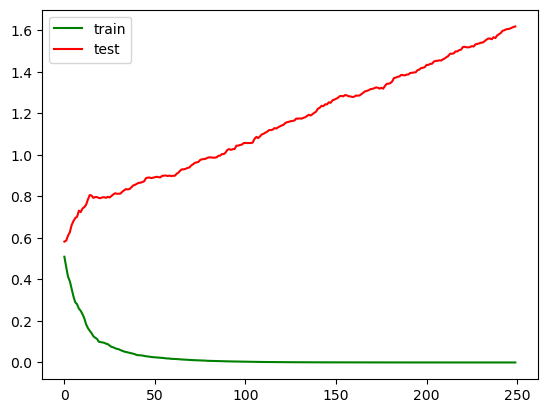

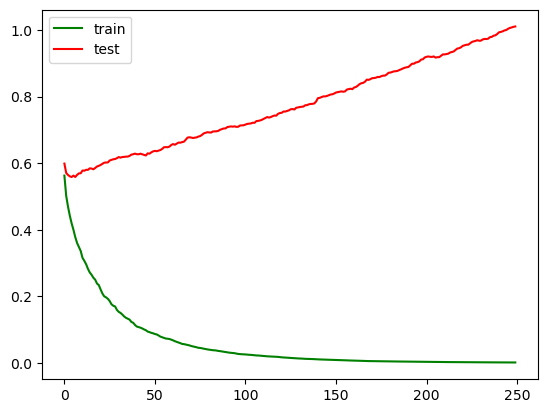

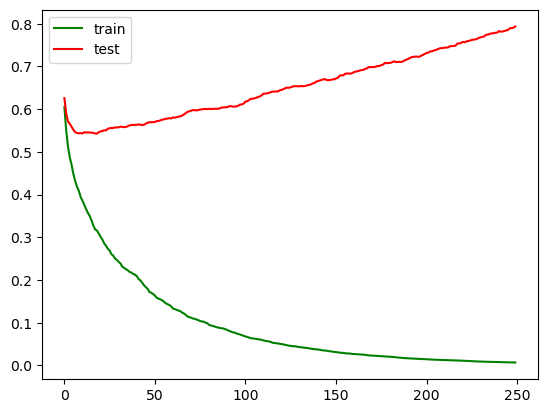

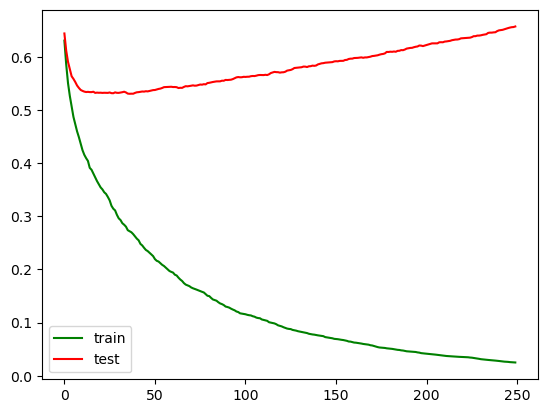

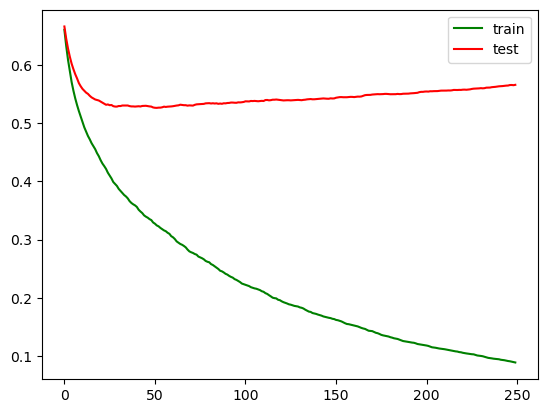

In [3]:
for learning_rate in [1.0, 0.5, 0.3, 0.2, 0.1]:
    model = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=learning_rate)
    model.fit(X_train, y_train)
    scores_train = []
    for y_pred in model.staged_decision_function(X_train):
        y_p = 1 / (1 + np.exp(-y_pred))
        scores_train.append(log_loss(y_train, y_p))
    scores_test = []
    for y_pred in model.staged_decision_function(X_test):
        y_p = 1 / (1 + np.exp(-y_pred))
        scores_test.append(log_loss(y_test, y_p))
    if learning_rate == 0.2:
        score4 = scores_test
    plt.figure()
    plt.plot(scores_train, 'g')
    plt.plot(scores_test, 'r')
    plt.legend(['train', 'test'])

3. Как можно охарактеризовать график качества на тестовой выбор
ке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

In [4]:
answer3 = 'overfitting'
print(answer3)

overfitting


4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.

In [5]:
score = pd.Series(score4)
answer41 = score.min()
answer42 = score.idxmin() + 1
print(answer41, answer42)

0.530518587320272 37


5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пунк
та, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного ле
са? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)

In [6]:
model = RandomForestClassifier(n_estimators=answer42, random_state=241)
model.fit(X_train, y_train)
answer5 = log_loss(y_test, model.predict_proba(X_test))
print(answer5)

0.5410941951182815
